# How to determine energy transfer efficiencies

In [1]:
import os
import sys

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

### Simple example

In [4]:
efficiency = fo.calculate_fret_efficiency(fret_rate=1e8, fluorescence_lifetime=1e-9)
print(f"{efficiency:.2e}")

9.09e-02


### Efficiencies vs distance

In [17]:
J_1 = 1e15
J_2 = 1e10
orient = 2 / 3
emission_rate = 1e8
refractive_index = 1
tau_fl = 1e-9

rates_J1 = []
distances = np.arange(1, 12, 1)
for distance in distances:
    rate = fo.calculate_fret_rate(
        distance=distance,
        emission_rate=emission_rate,
        spectral_overlap_integral=J_1,
        dipole_orientation_factor=orient,
        refractive_index=refractive_index,
    )
    rates_J1.append(rate)

efficiencies_J1 = []
for rate in rates_J1:
    e = fo.calculate_fret_efficiency(rate, fluorescence_lifetime=tau_fl)
    efficiencies_J1.append(e)

rates_J2 = []
distances = np.arange(1, 12, 1)
for distance in distances:
    rate = fo.calculate_fret_rate(
        distance=distance,
        emission_rate=emission_rate,
        spectral_overlap_integral=J_2,
        dipole_orientation_factor=orient,
        refractive_index=refractive_index,
    )
    rates_J2.append(rate)

efficiencies_J2 = []
for rate in rates_J2:
    e = fo.calculate_fret_efficiency(rate, fluorescence_lifetime=tau_fl)
    efficiencies_J2.append(e)

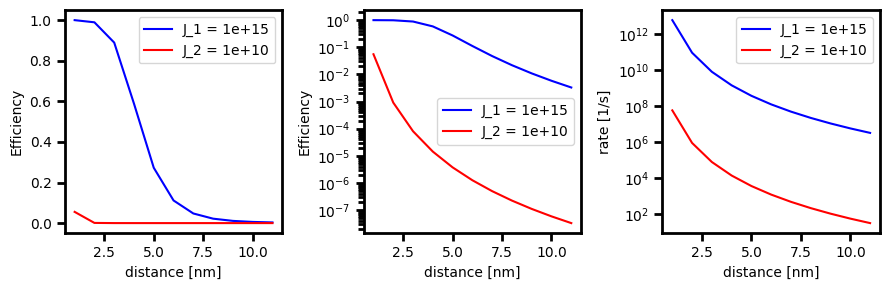

In [19]:
axes = fi.universal_figure(
    data=[distances, efficiencies_J1],
    ylabel="Efficiency",
    xlabel="distance [nm]",
    ncols=3,
    fontsize=10,
    fig_width=9,
    label=f"{J_1 = :.0e}",
    legend=True,
)
fi.universal_figure(
    data=[distances, efficiencies_J1],
    ylabel="Efficiency",
    xlabel="distance [nm]",
    fontsize=10,
    axes=axes[0, 1],
    yscale="log",
    label=f"{J_1 = :.0e}",
    legend=True,
)
fi.universal_figure(
    type_="line",
    data=[distances, rates_J1],
    ylabel="rate [1/s]",
    xlabel="distance [nm]",
    yscale="log",
    legend=True,
    label=f"{J_1 = :.0e}",
    axes=axes[0, 2],
    fontsize=10,
)
fi.universal_figure(
    data=[distances, efficiencies_J2],
    ylabel="Efficiency",
    xlabel="distance [nm]",
    axes=axes[0, 0],
    fontsize=10,
    fig_width=9,
    label=f"{J_2 = :.0e}",
    legend=True,
    color="red",
)
fi.universal_figure(
    data=[distances, efficiencies_J2],
    ylabel="Efficiency",
    xlabel="distance [nm]",
    fontsize=10,
    axes=axes[0, 1],
    yscale="log",
    label=f"{J_2 = :.0e}",
    legend=True,
    color="red",
)
fi.universal_figure(
    type_="line",
    data=[distances, rates_J2],
    ylabel="rate [1/s]",
    xlabel="distance [nm]",
    yscale="log",
    legend=True,
    label=f"{J_2 = :.0e}",
    axes=axes[0, 2],
    fontsize=10,
    color="red",
)
figure = mi.get_figure(axes)
figure.tight_layout()